# Clase del 24 de agosto: Decision Tree (DT)

In [16]:
# Stuff for importing dataset
import ssl
import certifi
from urllib.request import urlopen
import ssl
import certifi
from urllib.request import urlopen
import pandas as pd

url_data = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
ssl_context = ssl.create_default_context(cafile=certifi.where())

col_names = ['sepal_length','sepal_width', 'petal_length', 'petal_width', 'type']
with urlopen(url_data, context=ssl_context) as response:
    data = pd.read_csv(response,skiprows=1, header=None, names=col_names)
    # skiprows=1 skips the first row of the CSV

# print(data)


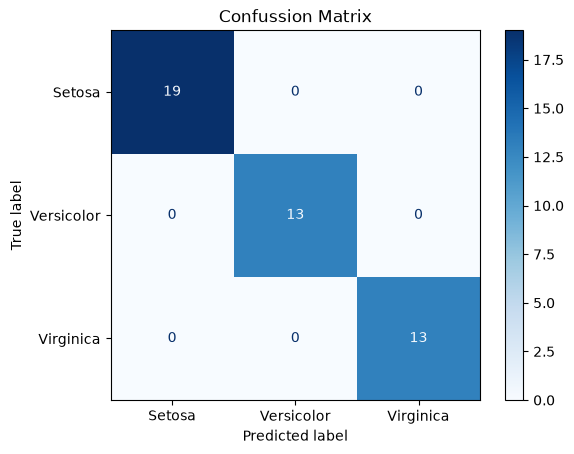

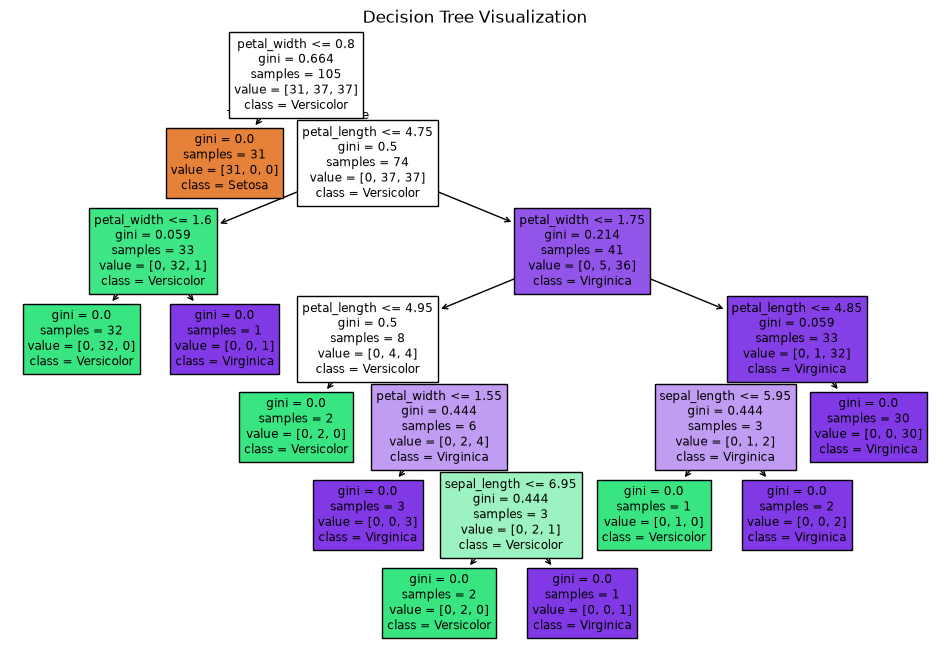

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


X = data.drop('type', axis=1) # Dropping the column type
y = data['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confussion Matrix")
plt.show()
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.title("Decision Tree Visualization")
plt.show()